# PSO for Perceptual Image Denoising
Given noisy image $v$, find $\hat{u}$ minimising:
$$\mathcal{L}_p(\hat{u}_p) = 1 - \text{SSIM}(\hat{u}_p, v_p) + \lambda \cdot \text{TV}(\hat{u}_p), \quad \hat{u}_k \in [0,1]$$
Strategy: split into patches, optimise each independently in parallel, stitch back.

In [15]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage import util
from PIL import Image
import pyswarms
import time
import multiprocess as multiprocessing

In [75]:
# parameters
patch_shape = (16, 16)

n_particles = 20
n_iter = 100

tv_lambda = 0.1
w = 0.7
c1 = 1.5
c2 = 1.5

### 1 – Preprocessing

Image format, size, color mode: (None, (512, 512), 'L')
Shape of patched image: (32, 32, 16, 16)
Patch size: (16, 16)


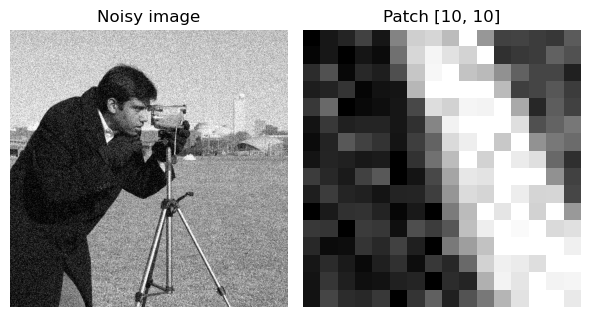

In [71]:
# convert to grayscale (without: PNG (512, 512) RGBA)
with Image.open("noisy_image.png") as im:
    im_grey = im.convert("L")
print(f"Image format, size, color mode: {im_grey.format, im_grey.size, im_grey.mode}")

# normalize 
im_n = np.array(im_grey)/255

# divide image into patches
patches_im_n = util.view_as_blocks(im_n, patch_shape)
print(f"Shape of patched image: {patches_im_n.shape}")

# select a patch for workflow development
v_patch = patches_im_n[10, 10]
print(f"Patch size: {v_patch.shape}")

# visualize image and selected patch
fig, axes = plt.subplots(1, 2, figsize=(6, 4))
axes[0].imshow(im_n, cmap="gray")
axes[0].set_title("Noisy image")
axes[0].axis("off")

axes[1].imshow(v_patch, cmap="gray")
axes[1].set_title("Patch [10, 10]")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 1.2 – Total variation (TV) and objective function
$$\text{TV}(\hat{u}) = \sum_{i,j} \sqrt{(\hat{u}_{i+1,j} - \hat{u}_{i,j})^2 + (\hat{u}_{i,j+1} - \hat{u}_{i,j})^2}$$
Given noisy image $v$, find $\hat{u}$ minimising:
$$\mathcal{L}_p(\hat{u}_p) = 1 - \text{SSIM}(\hat{u}_p, v_p) + \lambda \cdot \text{TV}(\hat{u}_p), \quad \hat{u}_k \in [0,1]$$

In [81]:
# compute difference between each pixel and its right resp. bottom neighbour, drop last column resp. row to address shape differences, then compute TV
def tv(u_patch):
    diff_down = u_patch[1:, :-1] - u_patch[:-1, :-1]
    diff_right = u_patch[:-1, 1:] - u_patch[:-1, :-1]
    return np.sum(np.sqrt(diff_down**2 + diff_right**2))

def loss(u_patch, v_patch):
    ssim_patch = ssim(u_patch, v_patch, data_range = 1.0, full=False, gradient=False)
    return 1.0 - float(ssim_patch) + tv_lambda*tv(u_patch)

In [80]:
# check (0-0 + 0.1 x 46.1)
tv(v_patch)
loss(v_patch, v_patch)

np.float64(46.1332567152585)

### 2 — PSO from Scratch
$$v_i^{t+1} = w \cdot v_i^t + c_1 r_1 (p_i - x_i^t) + c_2 r_2 (g - x_i^t)$$
$$x_i^{t+1} = x_i^t + v_i^{t+1}$$
Params: $w=0.7$, $c_1=c_2=1.5$, 20 particles, 100 iterations. Clip $x \in [0,1]$, clamp $v \in [-0.1, 0.1]$.
Run on one 16×16 patch. Output: convergence curve.

### 3 — PSO via pyswarms
Same patch, same hyperparameters. Cross-validate final $\mathcal{L}_p$ against Section 2.

### 4 — Full Image Pipeline
Split 512×512 → 1024 patches of 16×16. Run PSO per patch via `multiprocessing.Pool`. Stitch back.
Boundary artefacts expected: cross-patch TV terms are dropped in the per-patch decomposition.

### 5 — Results
Per method: convergence curve, wall-clock time, final $\mathcal{L}_p$. Visual: noisy vs. denoised.